In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Hàm nhỏ để hiển thị ảnh nhanh gọn trong Jupyter
def show_image(img, title="Image", is_gray=False):
    plt.figure(figsize=(6, 6))
    if is_gray:
        # Nếu là ảnh xám, cần báo cho matplotlib biết qua tham số cmap
        plt.imshow(img, cmap='gray')
    else:
        # Nếu là ảnh màu BGR, chuyển sang RGB trước khi show
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        
    plt.title(title)
    plt.axis('off')
    plt.show()

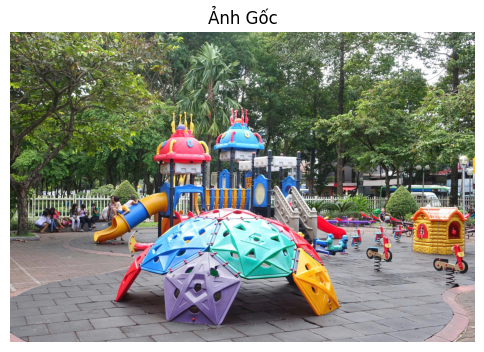

Đã lưu ảnh thành output.png


In [11]:
# Đọc ảnh
img = cv2.imread('lab01.jpg')

if img is None:
    print("Không tìm thấy ảnh!")
else:
    # Hiển thị ảnh bằng hàm đã tạo ở Cell 1
    show_image(img, "Ảnh Gốc")
    
    # Lưu ảnh sang định dạng PNG
    cv2.imwrite('output.png', img)
    print("Đã lưu ảnh thành output.png")

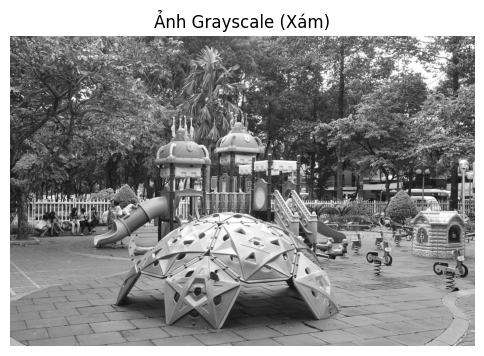

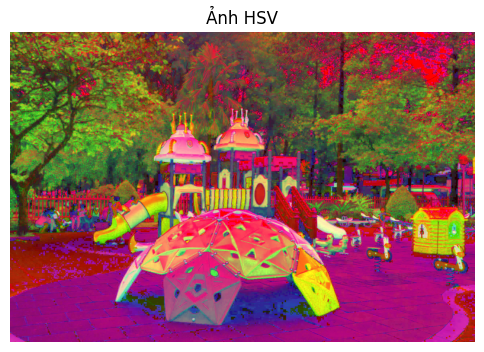

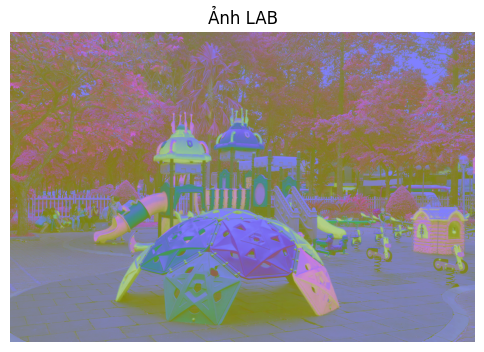

In [12]:
# Các hàm này tạo ra biến mới, không làm hỏng biến 'img' gốc
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Hiển thị thử ảnh xám
show_image(gray_img, "Ảnh Grayscale (Xám)", is_gray=True)
# Hiển thị ảnh HSV
show_image(hsv_img, "Ảnh HSV")
# Hiển thị ảnh LAB
show_image(lab_img, "Ảnh LAB")

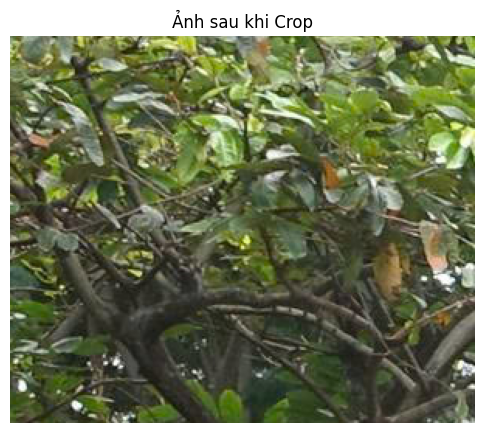

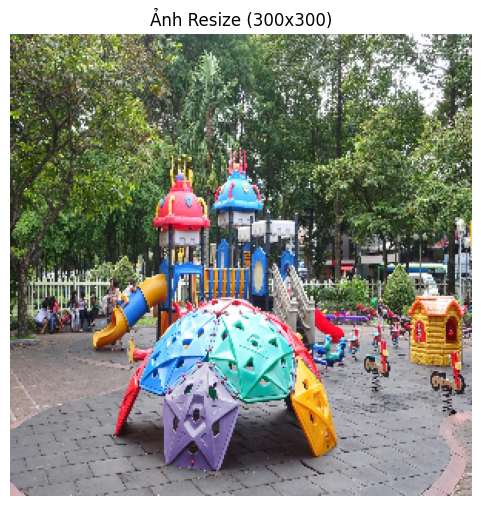

In [13]:
# Cắt ảnh (Sinh ra ma trận mới)
# Cú pháp: img[y_start:y_end, x_start:x_end]
cropped_img = img[50:300, 100:400] 
show_image(cropped_img, "Ảnh sau khi Crop")

# Resize ảnh theo kích thước cố định (Sinh ra ma trận mới)
resized_fixed = cv2.resize(img, (300, 300))
show_image(resized_fixed, "Ảnh Resize (300x300)")

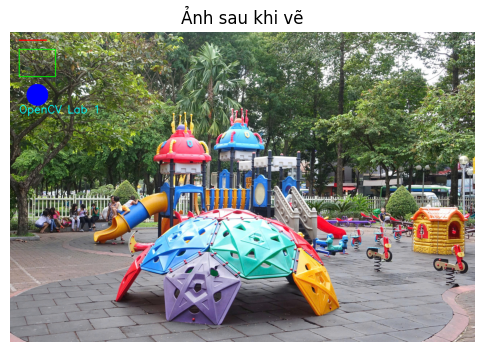

In [16]:
# ⚠️ QUAN TRỌNG: Dùng .copy() để không vẽ đè lên biến 'img' gốc
draw_img = img.copy()

# Vẽ đường thẳng (Màu đỏ - chuẩn BGR là (0, 0, 255))
cv2.line(draw_img, pt1=(50, 50), pt2=(200, 50), color=(0, 0, 255), thickness=5) 

# Vẽ hình chữ nhật (Màu xanh lá)
cv2.rectangle(draw_img, pt1=(50, 100), pt2=(250, 250), color=(0, 255, 0), thickness=3) 

# Vẽ hình tròn (Màu xanh biển, tô kín bằng thickness=-1)
cv2.circle(draw_img, center=(150, 350), radius=60, color=(255, 0, 0), thickness=-1) 

# Thêm văn bản
cv2.putText(draw_img, text='OpenCV Lab 1', org=(50, 450), 
            fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=2.0, 
            color=(255, 255, 0), thickness=3)

# Hiển thị kết quả
show_image(draw_img, "Ảnh sau khi vẽ")